# 1. Architettura dei Vision Transformer (ViT)


Il **Vision Transformer (ViT)** è un’architettura di deep learning progettata per elaborare immagini usando lo stesso tipo di rete *Transformer* che ha rivoluzionato il campo dell’elaborazione del linguaggio naturale (NLP).

A differenza delle **reti convoluzionali (CNN)**, che analizzano le immagini tramite convoluzioni per catturare dettagli locali, i Vision Transformer utilizzano il meccanismo di **self-attention** per modellare le relazioni globali tra diverse parti dell’immagine.

Questa architettura ha raggiunto risultati allo stato dell’arte in molti compiti di *computer vision*, come:

- classificazione di immagini,
- rilevamento di oggetti,
- segmentazione di immagini.
- generazione image->text e text->image

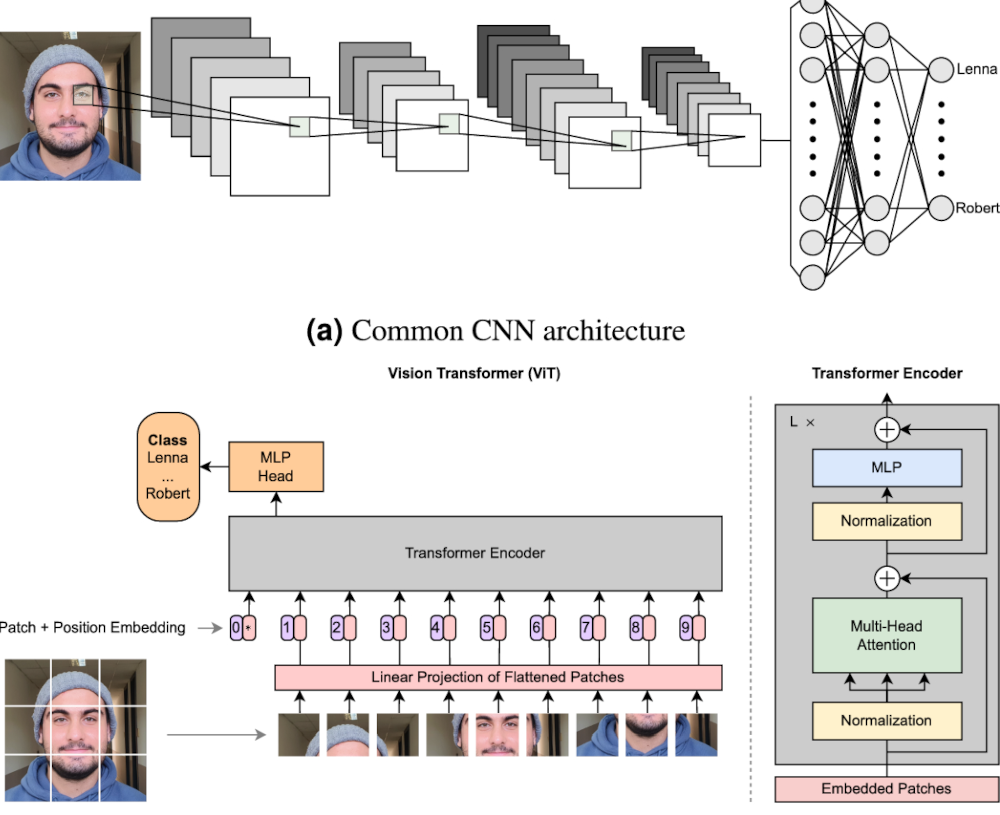

#### Riassunto dell’architettura del Vision Transformer

1. **Input:** L’immagine viene suddivisa in patch e codificata in vettori.
2. **Posizioni:** Si aggiungono codifiche posizionali per mantenere la struttura spaziale.
3. **Elaborazione:** Le patch passano attraverso più livelli Transformer con self-attention e reti feed-forward.
4. **Classificazione:** Il token [CLS] riassume le informazioni e viene usato dall’MLP finale per predire la categoria dell’immagine.

## 1.1 Addestramento

L’addestramento di un modello vision-language (cioè un modello che comprende sia immagini che testo) si basa sull’allineamento tra rappresentazioni visive e linguistiche.

#### Step 1. Rappresentazione separata di immagini e testo
Il modello parte da due componenti principali:

- Encoder visivo (di solito una CNN o un Transformer specializzato): trasforma un’immagine in un vettore numerico (embedding visivo) che cattura i contenuti visivi principali, come oggetti, colori e forme.

- Encoder testuale: trasforma il testo associato in un vettore numerico (embedding testuale) che rappresenta il significato semantico della frase.

- Entrambi gli encoder producono vettori di uguale dimensione che vivono nello stesso “spazio semantico”.

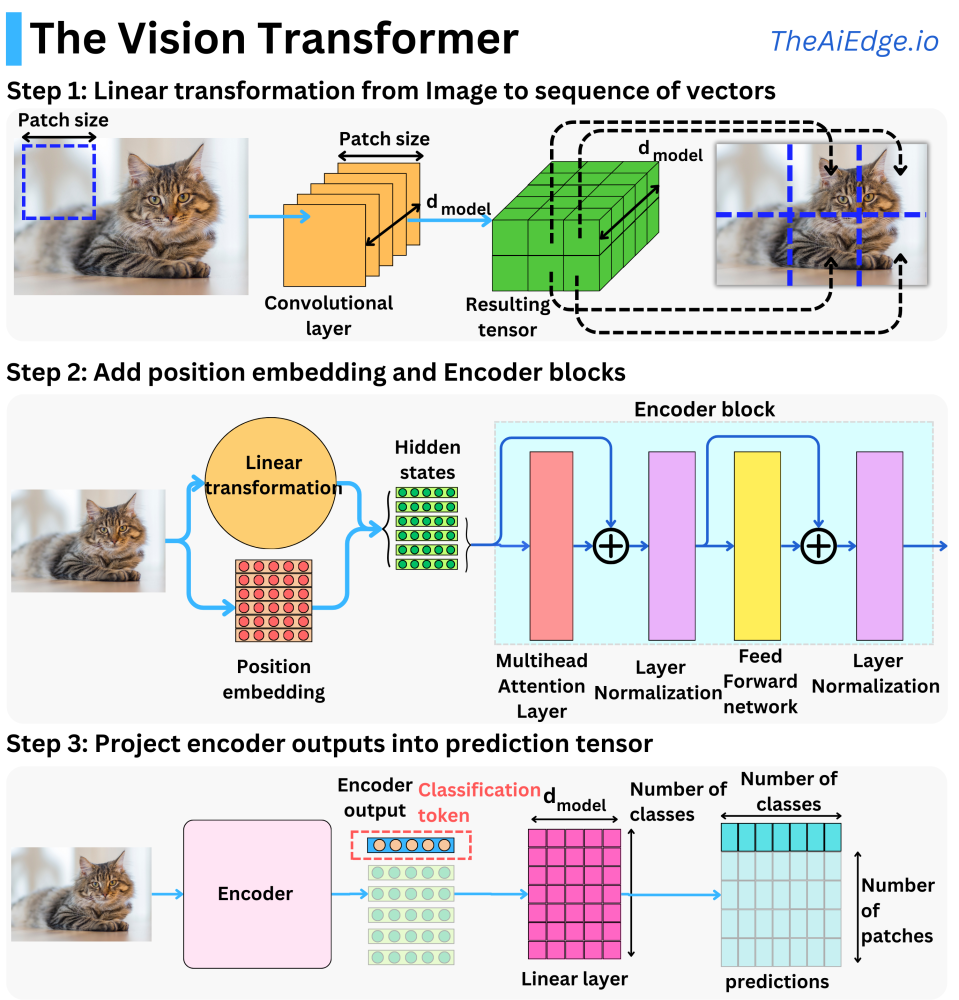

#### 2. Dataset di coppie immagine-testo

Il modello viene addestrato su grandi dataset di coppie (immagine, descrizione testuale).
Esempi:

“Un cane che corre sull’erba” → immagine con un cane su un prato.

“Una tazza di caffè su un tavolo di legno” → immagine corrispondente.

Queste coppie possono provenire da annotazioni umane (dataset curati come COCO, Flickr30k) oppure essere raccolte in modo automatico (ad esempio, testi alt nelle immagini del web).

#### 3. Obiettivo di allineamento (Contrastive Learning)

Durante l’addestramento, il modello impara a mettere vicini nel vettore spazio gli embedding delle immagini e dei testi che si corrispondono, e a tenere lontani quelli che non sono correlati.

Il metodo più comune è la **loss contrastiva** (come in CLIP di OpenAI):

1. Si prendono N immagini e N testi in un batch.

2. Per ogni immagine si calcola la similarità con tutti i testi (e viceversa).

3. Solo la coppia corretta deve avere la similarità più alta.

4. L’errore (loss) viene calcolato confrontando le similarità e aggiornando i pesi del modello per rinforzare le corrispondenze corrette.

In formule, si usa spesso una cross-entropy loss basata sulle similarità coseno tra vettori.

#### 4. Allineamento semantico

Alla fine dell’addestramento, il modello ha imparato una corrispondenza concettuale tra linguaggio e visione:

Se scrivi “gatto sul tappeto, il modello sa cercare un’immagine con quelle caratteristiche, perché il vettore del testo sarà vicino ai vettori di immagini simili.

Se gli si mostra un’immagine, può generare parole vicine nello spazio semantico che la descrivono (captioning).

# 2. Modello Multimodale con Ollama

In [1]:
from pathlib import Path
import os
# pip install python-dotenv
from dotenv import load_dotenv

CURRENT_DIR = Path(".")
load_dotenv(dotenv_path=CURRENT_DIR / "ollama_model.env")


True

In [2]:
from ollama import Client



class MultimodalAgent:
    def __init__(self):
        self.client =  Client(host='http://localhost:11434')
        self.model = os.getenv("OLLAMA_MODEL")
        print(f"MODEL: {self.model}")

    
    def complete(self,
                 user_message: str, 
                 image_path: Path | None = None, 
                 schema: dict | None = None, 
                 temperature: float = 0.5):

        if image_path is not None:
            messages = [{
                    "role": "user",
                    "content":  user_message,
                    "images": [image_path]
                }]
        else:
            messages = [{
                    "role": "user",
                    "content":  user_message
                }]
            
        format = None
        if schema is not None:
            format = schema

        response = self.client.chat(model=self.model, 
                                    messages=messages, 
                                    options={"temperature": temperature }, 
                                    format=format)


        return response['message']['content']

In [3]:
IMAGE_PATH = CURRENT_DIR / "images" / "salotto.jpg"

In [ ]:
def test_image_chat():

    user_message = "describe the image"

    agent = MultimodalAgent()

    response = agent.complete(user_message=user_message, 
                              image_path=IMAGE_PATH)
    
    print(response)


# run
test_image_chat()


In [5]:
from pydantic import BaseModel, Field
import json

class Furniture(BaseModel):
    type: str = Field(..., description="The type of furniture")
    description: str =  Field(..., description="A short description from the catalog max 20 words")
    quantity: int = Field(..., description="The number of the furnitures of the same type")
    position: str = Field(..., description="A short description of where the furniture is located, max 10 words")

class Decorations(BaseModel):
    type: str = Field(..., description="The type of decoration")
    description: str =  Field(..., description="A short description from the catalog")
    quantity: int = Field(..., description="The nubmer of the decoration of the same type")
    position: str = Field(..., description="A short description of where the decoration is located, max 10 words")

class Room(BaseModel):
    furnitures: list[Furniture] = Field(..., description="The list of furinutre if there are any")
    decorations: list[Decorations] = Field(..., description="The list of decorations if there are any")



print(json.dumps(Room.model_json_schema(), indent=4))

{
    "$defs": {
        "Decorations": {
            "properties": {
                "type": {
                    "description": "The type of decoration",
                    "title": "Type",
                    "type": "string"
                },
                "description": {
                    "description": "A short description from the catalog",
                    "title": "Description",
                    "type": "string"
                },
                "quantity": {
                    "description": "The nubmer of the decoration of the same type",
                    "title": "Quantity",
                    "type": "integer"
                },
                "position": {
                    "description": "A short description of where the decoration is located, max 10 words",
                    "title": "Position",
                    "type": "string"
                }
            },
            "required": [
                "type",
                "description",
 

In [ ]:
def test_image_chat_with_json_output():

    user_message = "room description"

    agent = MultimodalAgent()

    response = agent.complete(user_message=user_message, 
                              image_path=IMAGE_PATH,
                              schema=Room.model_json_schema())
    
    response = response
    data_dict = json.loads(response)

    print(data_dict)

    with open("room.json", 'w') as json_file:
        json.dump(data_dict, json_file, indent=4)
    
test_image_chat_with_json_output()

# 3. Multimodal RAG

Funzione di embedding: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

```bash
pip install sentence_transformers pillow chromadb
```

> **Nota sugli embedding:** In questa implementazione il retrieval è interamente testuale: ogni record viene indicizzato con la **descrizione testuale** dell'immagine usando `all-MiniLM-L6-v2`. L'URI dell'immagine viene salvato nei metadati e restituito insieme ai risultati, ma non contribuisce all'embedding — la ricerca trova immagini "simili" solo perché le loro descrizioni sono semanticamente vicine.
>
> Per un vero multimodal RAG si userebbe **CLIP** (`clip-ViT-B-32`) che codifica immagini e testo nello stesso spazio vettoriale, permettendo query del tipo "trova immagini visivamente simili a questa foto".

In [ ]:
import chromadb
from chromadb.utils import embedding_functions
import uuid


# Per sopprimere i warning sui notebok di python


class MultimodalVdb:
    def __init__(self):
        self.chroma_client = chromadb.PersistentClient(path=CURRENT_DIR / "mvdb")
        self.collection = None

    def create_collection(self):
        # Setup multimodal components
        collection_name = "multimodal_rag"

        embedding_function = embedding_functions.SentenceTransformerEmbeddingFunction(
                                    model_name="all-MiniLM-L6-v2"  # Piccolo: ~80MB, MOLTO veloce
                                )
                
        self.collection = self.chroma_client.get_or_create_collection(
                name=collection_name,
                embedding_function=embedding_function
            )
        
    def insert(self, text: str, image_path: Path | None = None, metadata: dict | None = None):
        doc_id = str(uuid.uuid4())

        meta = metadata or {}
        if image_path and image_path.exists():
            meta["image_uri"] = str(image_path)

        # L'embedding viene sempre fatto sul testo (all-MiniLM-L6-v2 è testo-only).
        # L'URI dell'immagine viene salvato nei metadati per il retrieval.
        self.collection.add(
            ids=[doc_id],
            documents=[text],
            metadatas=[meta]
        )

    def retrieve(self, query: str, top_k: int = 3):
        results = self.collection.query(
            query_texts=[query],
            n_results=top_k,
            include=['metadatas', 'documents', 'distances']
        )
        return results
    

multimodal_rag = MultimodalVdb()
multimodal_rag.create_collection()

In [ ]:
def insert_cat_data():
    # Setup
    collection = multimodal_rag.collection

    cat_path = CURRENT_DIR / "images" / "gatto.jpg"
    if cat_path.exists():
        multimodal_rag.insert(
            text="Un gatto che dorme su un tappeto",
            image_path=cat_path,
            metadata={"type": "animal", "species": "cat", "activity": "sleeping"}
        )

    multimodal_rag.insert(
            text="I gatti sono animali domestici che amano dormire e sono molto indipendenti.",
            metadata={"type": "text", "topic": "cats"}
        )
    print(f"\n=== Collection Status: {collection.count()} items ===\n")


# INSERT 
insert_cat_data()

In [ ]:
def insert_dog_data():
    print("=== Multimodal RAG Setup ===\n")
    
    collection = multimodal_rag.collection

        
        
    dog_path = CURRENT_DIR / "images" / "cane.jpg"
    if dog_path.exists():
        multimodal_rag.insert(
            text="Un cane che gioca con una palla",
            image_path=dog_path,
            metadata={"type": "animal", "species": "dog", "activity": "playing"}
        )
    print(f"Inert image: {dog_path}")

   
    multimodal_rag.insert(
        text="I cani sono animali fedeli che amano giocare e fare attività all'aperto.",
        metadata={"type": "text", "topic": "dogs"}
    )
    
    print(f"\n=== Collection Status: {collection.count()} items ===\n")
    
# INSERT 
insert_dog_data()

In [ ]:
def retrieve_data():
    # Test queries
    queries = [
        "Quale animale è raffigurato che gioca con una palla?",
        "Mostrami un animale che dorme",
        "Descrivi gli animali domestici"
    ]

    for query in queries:
        print("=====================================")
        print(f"Query: {query}")
        answer = multimodal_rag.retrieve(query=query, top_k = 3)
        if answer:
            print("Text answers: ")
            for doc in answer['documents'][0]: 
                if doc is not None: print(f" {doc}")

            print("Images answers: ")
            if "metadatas" in answer:
                for md in answer['metadatas'][0]:
                    if md and "image_uri" in md:
                        print(f" {md['image_uri']}")

            print("Metadati answers: ")
            if "metadatas" in answer:
                for md in answer['metadatas'][0]: 
                    if md is not None: print(f" {md}")
         
# RUN
retrieve_data()